<a href="https://colab.research.google.com/github/sachini-g/Prediction-of-TATA-DNA-Sequence/blob/main/DNAsequenceprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d harshvardhan21/dna-sequence-prediction

Dataset URL: https://www.kaggle.com/datasets/harshvardhan21/dna-sequence-prediction
License(s): MIT
  0% 0.00/4.78M [00:00<?, ?B/s]
100% 4.78M/4.78M [00:00<00:00, 1.12GB/s]


In [ ]:
#extracting dataset from zipfile
from zipfile import ZipFile
dataset = '/content/dna-sequence-prediction.zip'

with ZipFile(dataset,'r') as zip_ref:
  zip_ref.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [ ]:
import pandas as pd
train_data = pd.read_csv('/content/train.csv')
test_data = pd.read_csv('/content/test.csv')
valid_data = pd.read_csv('/content/validation.csv')

In [ ]:
train_data.head()

,Unnamed: 0,NCBIGeneID,Symbol,Description,GeneType,GeneGroupMethod,NucleotideSequence
0,0,106481178,RNU4-21P,"RNA, U4 small nuclear 21, pseudogene",PSEUDO,NCBI Ortholog,<AGCTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAG...
1,1,123477792,LOC123477792,Sharpr-MPRA regulatory region 12926,BIOLOGICAL_REGION,NCBI Ortholog,<CTGGAGCGGCCACGATGTGAACTGTCACCGGCCACTGCTGCTCCG...
2,2,113174975,LOC113174975,Sharpr-MPRA regulatory region 7591,BIOLOGICAL_REGION,NCBI Ortholog,<TTCCCAATTTTTCCTCTGCTTTTTAATTTTCTAGTTTCCTTTTTC...
3,3,116216107,LOC116216107,CRISPRi-validated cis-regulatory element chr10...,BIOLOGICAL_REGION,NCBI Ortholog,<CGCCCAGGCTGGAGTGCAGTGGCGCCATCTCGGCTCACTGCAGGC...
4,4,28502,IGHD2-21,immunoglobulin heavy diversity 2-21,OTHER,NCBI Ortholog,<AGCATATTGTGGTGGTGACTGCTATTCC>


In [ ]:
train_data.tail()

,Unnamed: 0,NCBIGeneID,Symbol,Description,GeneType,GeneGroupMethod,NucleotideSequence
22588,19009,124907055,LOC124907055,uncharacterized LOC124907055,ncRNA,NCBI Ortholog,<GGTGGGGTGGGGTGGGGTGGGGTGGGGTGCAGAGAAAACGATTGA...
22589,19012,106480032,RNU6-1060P,"RNA, U6 small nuclear 1060, pseudogene",PSEUDO,NCBI Ortholog,<GTGCTCACTTCAGCAGCACATATACTAAAATTGGAATGATACAGA...
22590,19015,106481029,RN7SL387P,"RNA, 7SL, cytoplasmic 387, pseudogene",PSEUDO,NCBI Ortholog,<GCTGGGCGTGGTGGTGGGTGCCTGTAATCCCAGCTACTAGGGAGG...
22591,19019,100286918,NDUFS5P2,NADH:ubiquinone oxidoreductase subunit S5 pseu...,PSEUDO,NCBI Ortholog,<TCGTCCTGAAGCAGCGGCCAGAGAAGAGACAAGGGCACGAGCATC...
22592,19021,100189280,TRA-TGC3-1,tRNA-Ala (anticodon TGC) 3-1,tRNA,NCBI Ortholog,<GGGGATGTAGCTCAGTGGTAGAGCGCATGCTTTGCATGTATGAGG...


In [ ]:
train_data = pd.DataFrame(train_data)

In [ ]:
print(train_data.dtypes)

Unnamed: 0             int64
NCBIGeneID             int64
Symbol                object
Description           object
GeneType              object
GeneGroupMethod       object
NucleotideSequence    object
dtype: object


In [ ]:
import pandas as pd
import re


# Example motif patterns
# W = [A or T], R = [A or G]
motifs = {
    "TATAAA": "TATAAA",
    "TATAWAWR": "TATA[AT]A[AG][AG]"  # Already replaced W and R
}

# Function to check if any motif exists in a sequence
def motif_present(sequence, motifs):
    for motif_pattern in motifs.values():
        if re.search(motif_pattern, sequence):
            return 1
    return 0

# Apply to your DataFrame
train_data['MotifPresent'] = train_data['NucleotideSequence'].apply(lambda x: motif_present(x, motifs))
test_data['MotifPresent'] = test_data['NucleotideSequence'].apply(lambda x: motif_present(x, motifs))
valid_data['MotifPresent'] = valid_data['NucleotideSequence'].apply(lambda x: motif_present(x, motifs))

# Check results
print(train_data)
print(test_data)
print(valid_data)



       Unnamed: 0  NCBIGeneID        Symbol  \
0               0   106481178      RNU4-21P   
1               1   123477792  LOC123477792   
2               2   113174975  LOC113174975   
3               3   116216107  LOC116216107   
4               4       28502      IGHD2-21   
...           ...         ...           ...   
22588       19009   124907055  LOC124907055   
22589       19012   106480032    RNU6-1060P   
22590       19015   106481029     RN7SL387P   
22591       19019   100286918      NDUFS5P2   
22592       19021   100189280    TRA-TGC3-1   

                                             Description           GeneType  \
0                   RNA, U4 small nuclear 21, pseudogene             PSEUDO   
1                    Sharpr-MPRA regulatory region 12926  BIOLOGICAL_REGION   
2                     Sharpr-MPRA regulatory region 7591  BIOLOGICAL_REGION   
3      CRISPRi-validated cis-regulatory element chr10...  BIOLOGICAL_REGION   
4                    immunoglobulin heav

In [ ]:
train_data['MotifPresent'].value_counts()

,count
MotifPresent,
0,20566
1,2027


In [ ]:
# Assuming 'MotifPresent' is your target column
from collections import Counter

# Check current distribution
print(Counter(train_data['MotifPresent']))

# Separate classes
class_0 = train_data[train_data['MotifPresent'] == 0]
class_1 = train_data[train_data['MotifPresent'] == 1]

# Find minority class size
min_size = min(len(class_0), len(class_1))

# Randomly sample from each class
class_0_balanced = class_0.sample(n=min_size, random_state=42)
class_1_balanced = class_1.sample(n=min_size, random_state=42)

# Combine and shuffle
balanced_data = pd.concat([class_0_balanced, class_1_balanced])
balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)

print(Counter(balanced_data['MotifPresent']))

Counter({0: 20566, 1: 2027})
Counter({0: 2027, 1: 2027})


In [ ]:
X = balanced_data[['NCBIGeneID', 'NucleotideSequence']]
y = balanced_data['MotifPresent']

In [ ]:
X.shape

(4054, 2)

In [ ]:
y.shape

(4054,)

In [ ]:
X.head()

,NCBIGeneID,NucleotideSequence
0,100127922,<CTCCTGGTGCTGCTTGTGTGCTTGTTTGGTACGGACCTGGTACCT...
1,26864,<ATACTTACCTGGCAGGGGAGATACCATGATCACGAAGGTGGTTTT...
2,54574,<ATGGCTCCTGCTGGGTGGAACGGCCCCCTTCACCTATGTGTGTGT...
3,121847947,<ATGTAAACAACAGTATAAACGAACCCAACCTGATGGTTTTACAGT...
4,123575672,<CACGATTTTGGGGGATGCAATAGTGATTCATGCCTTTGAAAATTT...


In [ ]:
y.head()

,MotifPresent
0,0
1,0
2,0
3,1
4,0


We are making a set of data in which only the Nucleotide is considered

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenizing nucleotide sequences
tokenizer = Tokenizer(char_level=True)  # Important: use char_level for DNA
tokenizer.fit_on_texts(balanced_data['NucleotideSequence'])

# Convert sequences to numbers
X_train = pad_sequences(
    tokenizer.texts_to_sequences(balanced_data['NucleotideSequence']),
    maxlen=200  # Adjust based on your sequence length
)

X_test = pad_sequences(
    tokenizer.texts_to_sequences(test_data['NucleotideSequence']),
    maxlen=200
)

# Your target variable
y_train = balanced_data['MotifPresent'].values
y_test = test_data['MotifPresent'].values

# Check the tokenization
print("Tokenizer word index:", tokenizer.word_index)  # Should show: {'a': 1, 't': 2, 'g': 3, 'c': 4}
print("X_train shape:", X_train.shape)
print("Sample encoded sequence:", X_train[0])


Tokenizer word index: {'a': 1, 't': 2, 'g': 3, 'c': 4, '<': 5, '>': 6}
X_train shape: (4054, 200)
Sample encoded sequence: [1 1 1 3 3 3 1 1 4 4 2 3 4 2 2 4 2 2 2 1 4 2 4 4 1 3 1 1 4 2 4 2 3 2 2 4 2
 2 2 1 1 1 3 1 4 4 1 1 3 1 2 2 1 4 1 2 2 4 3 4 1 1 2 2 1 3 1 1 1 1 4 2 3 4
 1 1 4 2 2 3 3 2 2 4 4 1 4 4 1 4 1 2 4 4 2 3 1 4 2 1 4 2 1 4 4 1 2 1 2 1 3
 2 2 2 2 4 2 4 2 1 2 2 4 2 2 2 4 1 4 2 2 4 4 3 4 4 2 2 4 4 4 4 1 2 2 4 4 2
 2 2 1 2 2 3 2 1 2 3 2 1 1 1 3 2 1 1 4 2 3 3 2 1 2 1 2 3 2 3 4 1 4 1 1 3 4
 1 2 1 2 2 3 4 1 2 2 2 2 2 2 6]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

# Model for DNA sequence classification
model = Sequential()

# Embedding layer
# input_dim = 5 (for A, T, G, C + padding token)
# output_dim = 32 (smaller embedding for simple nucleotide vocabulary)
# input_length = length of your DNA sequences
model.add(Embedding(input_dim=5, output_dim=32, input_length=200, mask_zero=True))

# Bidirectional LSTM layers
model.add(Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2, return_sequences=True)))
model.add(Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2)))

# Optional: Additional dropout for regularization
model.add(Dropout(0.3))

# Output layer for binary classification (TATA vs non-TATA)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

# View model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Tokenize and pad the validation sequences (same as you did for train/test)
X_valid = pad_sequences(
    tokenizer.texts_to_sequences(valid_data['NucleotideSequence']),
    maxlen=200
)

# Convert target to proper dtype
y_valid = valid_data['MotifPresent'].values.astype('float32')

# Check the shapes and dtypes
print("X_valid shape:", X_valid.shape)
print("X_valid dtype:", X_valid.dtype)
print("y_valid shape:", y_valid.shape)
print("y_valid dtype:", y_valid.dtype)

# Now train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=20,
    batch_size=32,
    verbose=1
)

X_valid shape: (4577, 200)
X_valid dtype: int32
y_valid shape: (4577,)
y_valid dtype: float32
Epoch 1/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 404s 3s/step - AUC: 0.7059 - accuracy: 0.6541 - loss: 0.6237 - val_AUC: 0.6351 - val_accuracy: 0.3804 - val_loss: 0.8002
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 410s 3s/step - AUC: 0.6568 - accuracy: 0.6070 - loss: 0.6498 - val_AUC: 0.6543 - val_accuracy: 0.5943 - val_loss: 0.6422
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 448s 3s/step - AUC: 0.6626 - accuracy: 0.6055 - loss: 0.6426 - val_AUC: 0.6661 - val_accuracy: 0.6227 - val_loss: 0.6414
Epoch 4/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 436s 3s/step - AUC: 0.6869 - accuracy: 0.6283 - loss: 0.6379 - val_AUC: 0.6854 - val_accuracy: 0.5785 - val_loss: 0.6710
Epoch 5/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 455s 3s/step - AUC: 0.7112 - accuracy: 0.6446 - loss: 0.6193 - val_AUC: 0.7161 - val_accuracy: 0.7271 - val_loss: 0.5437
Epoch 6/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 406s 3s/step - AUC: 0.6760 - accuracy: 0.6307 - loss: 0.6522 

In [ ]:

# Evaluate
loss, accuracy, auc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test AUC: {auc:.4f}")

261/261 ━━━━━━━━━━━━━━━━━━━━ 118s 448ms/step - AUC: 0.8090 - accuracy: 0.7659 - loss: 0.4890
Test Accuracy: 0.7682
Test AUC: 0.8072


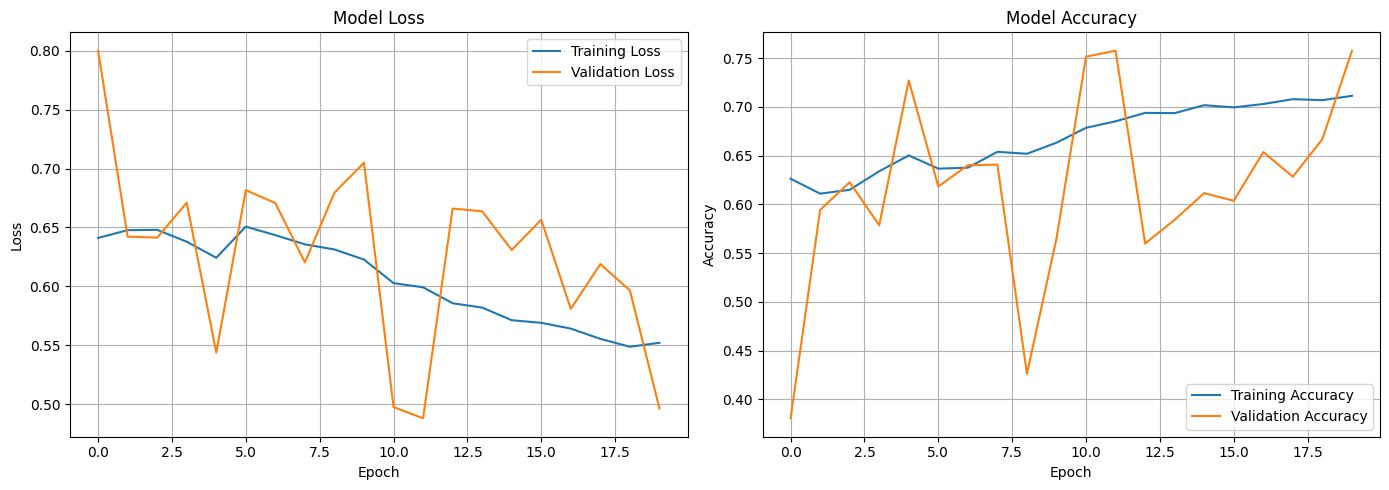

In [ ]:
import matplotlib.pyplot as plt

# Plot training history
def plot_history(history):
    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Loss
    ax1.plot(history.history['loss'], label='Training Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot Accuracy
    ax2.plot(history.history['accuracy'], label='Training Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Call the function
plot_history(history)

261/261 ━━━━━━━━━━━━━━━━━━━━ 121s 446ms/step


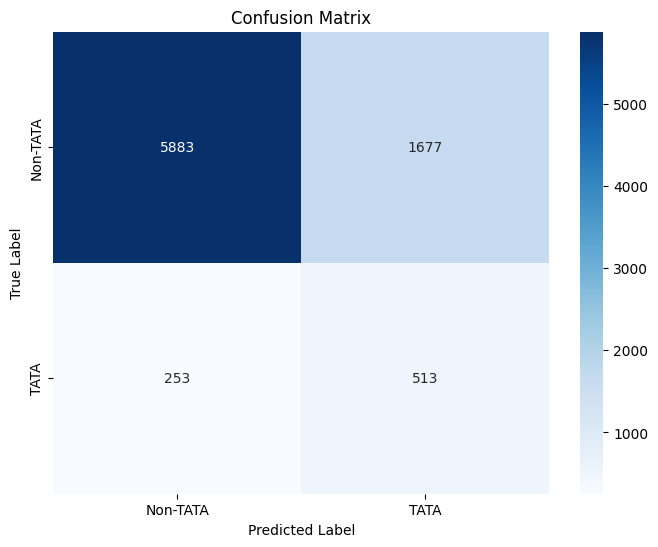


Classification Report:
              precision    recall  f1-score   support

    Non-TATA       0.96      0.78      0.86      7560
        TATA       0.23      0.67      0.35       766

    accuracy                           0.77      8326
   macro avg       0.60      0.72      0.60      8326
weighted avg       0.89      0.77      0.81      8326



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Make predictions on test set
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()  # Convert probabilities to binary

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-TATA', 'TATA'],
            yticklabels=['Non-TATA', 'TATA'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-TATA', 'TATA']))